<a href="https://colab.research.google.com/github/Mariano-ds/centollas2026/blob/main/mariano/mariano_tp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**

### Parte 3: Aprendizaje supervisado o no supervisado

---
## Mentoría 15: *¿Cuándo y dónde pescar Centollas en el Canal Beagle?*


**Objetivo**: Caracterizar los puntos de muestreo en base a la abundancia y las características de los ejemplares colectados para responder las demandas de la municipalidad.

1. **Caracterizar** los **puntos de muestreo** considerando los ejemplares pescados. Se debe considerar la variabilidad temporal.

2. **Agrupar** los puntos de muestreo mediante técnicas de análisis no supervisado.

3. **Describir** la variabilidad temporal.

4. **Redactar una recomendación** para el gobierno local que tenga por objetivo la subsistencia del recurso pesquero a lo largo del tiempo.

In [1]:
# Librerias utilizadas
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import plotly.express as px
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
import re

from scipy import stats

sns.set_context('talk')
pd.options.display.max_rows = 99999
pd.options.display.max_colwidth = 400

In [2]:
# Importo dataset original
url_original_data = "https://raw.github.com/luciabergagna-jpg/centoll/main/centollas_mentoria.csv"
data_original = pd.read_csv(url_original_data, sep=';', engine='python', encoding='latin1')

In [3]:
# Cargo el CSV local guardado en Drive con datos jul97
url_jul97 = 'https://raw.github.com/Mariano-ds/centollas2026/main/datos/jul97.csv'
data_jul97 = pd.read_csv(url_jul97, sep=';', engine='python', encoding='utf-8-sig')

In [4]:
# Estandarizacion previa - nombres de columnas
data_original.columns = data_original.columns.str.strip().str.lower()
data_jul97.columns = data_jul97.columns.str.strip().str.lower()

# Concatenar los DataFrames
# axis=0 une por filas alineando automáticamente por nombre de columna
# ignore_index=True reindexa las filas de 0 a N para evitar índices repetidos
df_full = pd.concat([data_original, data_jul97], axis=0, ignore_index=True)

# Confirmación de la estructura unificada
print(f"Filas totales: {df_full.shape[0]} | Columnas totales: {df_full.shape[1]}")
df_raw = df_full.copy()
df_raw.head(2)

Filas totales: 13114 | Columnas totales: 20


,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,ancho_caparazon,largo_quela,ancho_quela,huevos,parasito,observaciones,unnamed: 18,unnamed: 19
0,ene_96,1,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,1,4.0,3,87.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ene_96,2,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,2,77.1,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN


In [5]:
# Se eliminan columnas vacías generadas por separadores sobrantes al final de cada fila
df_raw.drop(columns=['unnamed: 18', 'unnamed: 19'], inplace=True)
df_raw.dropna(subset=['largo_caparazon'],how='any',inplace=True)
print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")

Filas: 13,087 | Columnas: 18


In [6]:
# Elimina la fila SOLO si latitud, longitud y localizacion son NaN simultáneamente
df_raw.dropna(subset=['latitud', 'longitud', 'localizacion'],how='all',inplace=True)
print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")

Filas: 9,105 | Columnas: 18


Debido al alto porcentaje de entradas nulas, se descartan las columnas `ancho_caparazon`, `largo_quela` y `ancho_quela`, pues no permiten sacar conclusiones sobre la muestra.


In [7]:
df_raw.drop(columns=['ancho_caparazon', 'largo_quela', 'ancho_quela'], inplace=True)

In [8]:
def extraer_num_trampas(tipo_str):
    """
    Extrae el número de trampas vinculando explícitamente la cantidad
    con los términos 'trampa' o 'linea'.
    """
    if pd.isna(tipo_str):
        return np.nan

    texto = str(tipo_str).lower()

    # 1. Patrón con número ANTES del término (ej: "10 trampas", "captura de 2 líneas")
    match_antes = re.search(r'(\d+\.?\d*)\s*(?:de\s*)?(trampa|línea|linea)', texto)

    # 2. Patrón con número DESPUÉS del término (ej: "trampas: 10", "línea 2")
    match_despues = re.search(r'(trampa|línea|linea)s?\s*(?::\s*|de\s*)?(\d+\.?\d*)', texto)

    if match_antes:
        numero = float(match_antes.group(1))
        unidad = match_antes.group(2)
    elif match_despues:
        unidad = match_despues.group(1)
        numero = float(match_despues.group(2))
    else:
        # Casos como "Captura total trampas wp 149" (sin cantidad especificada) o muestreos
        return np.nan

    # 3. Conversión de unidades (1 línea = 10 trampas)
    if 'linea' in unidad or 'línea' in unidad:
        return numero * 10.0
    return numero

In [9]:
# Aplicar función
df_raw['num_trampas'] = df_raw['tipo'].apply(extraer_num_trampas)

n_total = len(df_raw)
n_validos = df_raw['num_trampas'].notna().sum()
n_excluidos = n_total - n_validos

print("=="*50)
print(f" Registros con esfuerzo de pesca identificable: {n_validos} ({n_validos/n_total*100:.1f}%)")
print(f" Registros excluidos del cálculo de IAR (índice de abundancia relativa): {n_excluidos} ({n_excluidos/n_total*100:.1f}%)")
print("=="*50)

print("\nCategorías excluidas (sin equivalente en trampas):")
print(df_raw[df_raw['num_trampas'].isna()]['tipo'].value_counts())

 Registros con esfuerzo de pesca identificable: 8865 (97.4%)
 Registros excluidos del cálculo de IAR (índice de abundancia relativa): 240 (2.6%)

Categorías excluidas (sin equivalente en trampas):
tipo
Captura total trampas wp 149    110
Captura por la Wapisa            75
Muestreo de cubierta 3           55
Name: count, dtype: int64


In [10]:
# Definicion de la prioridad cronologica de las campañas
orden_campanas = {
    'ene_96': 1,
    'abril_96': 2,
    'jul_96': 3,
    'oct_96': 4,
    'jul_97': 5,
    'oct_97': 6,
    'oct_98': 7
}

# Se convierte a categorica y se ordena por fecha
df_raw['fecha'] = pd.Categorical(df_raw['fecha'], categories=orden_campanas, ordered=True)

# Se ordena con 'key' y se reinicia el índice
#df_raw = df_raw.sort_values(by='fecha', key=lambda x: x.map(orden_campanas)).reset_index(drop=True)

El porcentaje de nulos del dataframe de trabajo actualmente es el siguiente:

In [11]:
print("="*50)
print("Resumen de limpieza inicial - Estado actual del df")
print("="*50)

print(f"\nFilas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}\n")

# Estudio porcentual de valores nulos
faltantes = df_raw.isnull().mean().sort_values(ascending=False) * 100
print(faltantes[faltantes > 0].round(2))

Resumen de limpieza inicial - Estado actual del df

Filas: 9,105 | Columnas: 16

observaciones       98.58
parasito            97.25
cirripedio          86.23
huevos              62.47
longitud            12.73
latitud             12.73
num_trampas          2.64
profundidad          1.50
localizacion         1.21
estado_caparazon     0.02
dtype: float64


## 2. Corrección de columnas numéricas y categóricas

Estudiemos las variables que quedan con dtype str:  cirripedio, huevos y parasito.

Según la descripcion de los features provistos junto al dataset, hay una serie de columnas cuyos tipos son incorrectos. `estado_caparazon` es flotante en lugar de entero, y las columnas `cirripedio`, `huevos` y `parasito` figuran como str, en lugar de ser variables enteras.

In [12]:
# Copia posterior a la limpieza inicial
df_clean = df_raw.copy()

In [13]:
# Correccion cirripedio
# Diccionario de correcciones:
correcciones_cirripedio = {
    '2p': '2',
    '1p': '1'
}

# Aplicar el reemplazo
df_clean['cirripedio'] = df_clean['cirripedio'].replace(correcciones_cirripedio)
df_clean['cirripedio'] = df_clean['cirripedio'].apply(lambda x: float(x))

# Correccion parasitos
# Diccionario de correcciones:
correccion_parasito = {
    '3,20': '3', # Priorizo el parasito presente
    '30,20': '30'
}

# Aplicar el reemplazo
df_clean['parasito'] = df_clean['parasito'].replace(correccion_parasito)
df_clean['parasito'] = df_clean['parasito'].apply(lambda x: float(x))

# Correccion huevos
# Descarte de huevos = po
df_clean = df_clean[df_clean['huevos'] != 'po']

# Diccionario de correcciones:
correccion_huevos = {
    # Corrección de texto
    'conojos': '3',
    '7 en 1': '1'
}

# Aplicar el reemplazo
df_clean['huevos'] = df_clean['huevos'].replace(correccion_huevos)
df_clean['huevos'] = df_clean['huevos'].apply(lambda x: float(x))

Los registros disponibles permiten un estudio muy acotado de esta especie, por lo que se decide focalizar el resto del trabajo únicamente en los centollones.   

In [14]:
# Descarte de registros de centollas
df_segmented = df_clean[df_clean['especie'] != 1].copy()

# Tamaño del dataframe segmentado
print(f"Filas: {df_segmented.shape[0]:,} | Columnas: {df_segmented.shape[1]}")

Filas: 8,860 | Columnas: 16


## 4. Nuevos features

### 4.1 Indicador de madurez sexual

Habiendo segmentado los registros, se agrega una nueva columna booleana indicando si el centollón registrado es sexualmente maduro o no. Para ello, se utiliza el siguiente criterio a partir de información provista por nuestra mentora:

Si el largo del caparazón de un macho es al menos 50,2 mm, este es sexualmente maduro. En el caso de las hembras, su largo debe ser al menos 60,6 mm.

La codificación será entonces:

- 0 sexualmente inmaduro,
- 1 sexualmente maduro

In [15]:
# Condiciones de madurez según sexo y talla (mm)
macho_maduro = (df_segmented['sexo'] == 1) & (df_segmented['largo_caparazon'] >= 50.2)
hembra_madura = (df_segmented['sexo'] == 2) & (df_segmented['largo_caparazon'] >= 60.6)

# Nueva columna con codificación 1 (Maduro) y 0 (Inmaduro)
df_segmented['madurez_sexual'] = np.where(macho_maduro | hembra_madura, 1, 0)

# Tamaño del dataframe
print("="*50)
print("Resumen - Estado actual del df")
print("="*50)

print(f"\nFilas: {df_segmented.shape[0]:,} | Columnas: {df_segmented.shape[1]}\n")

# Estudio porcentual de valores nulos
faltantes = df_segmented.isnull().mean().sort_values(ascending=False) * 100
print(faltantes[faltantes > 0].round(2))

Resumen - Estado actual del df

Filas: 8,860 | Columnas: 17

observaciones    98.54
parasito         97.19
cirripedio       85.86
huevos           62.19
latitud          11.94
longitud         11.94
num_trampas       1.86
localizacion      1.24
profundidad       1.08
dtype: float64


Este dataframe será el punto de partida para responder a las preguntas solicitadas en este entregable, tomando los subconjuntos pertinentes en cada caso.

In [16]:
df_segmented.head()

,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,huevos,parasito,observaciones,num_trampas,madurez_sexual
0,ene_96,1,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,1,4.0,3.0,87.0,NaN,NaN,NaN,3.0,1
1,ene_96,2,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,2.0,77.1,1.0,NaN,NaN,3.0,1
2,ene_96,3,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,NaN,74.6,1.0,NaN,NaN,3.0,1
3,ene_96,4,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,1,3.0,NaN,75.6,NaN,NaN,NaN,3.0,1
4,ene_96,5,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,NaN,75.6,1.0,NaN,NaN,3.0,1


In [17]:
# Cuenta de fechas distintas por cada localizacion
fechas_por_loc = df_segmented.groupby('localizacion')['fecha'].nunique()

# Localizaciones con mas de 1 fecha
locs_multiples_fechas = fechas_por_loc[fechas_por_loc > 1]

print(
    f'Total de localizaciones con más de una fecha:'
    f' {len(locs_multiples_fechas)} de {len(fechas_por_loc)}'
)
print('\nDetalle de fechas por localización:')
print(locs_multiples_fechas)

Total de localizaciones con más de una fecha: 0 de 57

Detalle de fechas por localización:
Series([], Name: fecha, dtype: int64)


In [18]:
# Localizacion nula en df_segmented
df_segmented[df_segmented['localizacion'].isnull()]

,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,huevos,parasito,observaciones,num_trampas,madurez_sexual
11050,jul_97,1,Captura total trampas wp 149,NaN,-54.856333,-68.038,22.0,2,1,3.0,NaN,90.1,NaN,NaN,NaN,NaN,1
11051,jul_97,2,Captura total trampas wp 149,NaN,-54.856333,-68.038,22.0,2,1,3.0,NaN,87.2,NaN,NaN,NaN,NaN,1
11052,jul_97,3,Captura total trampas wp 149,NaN,-54.856333,-68.038,22.0,2,2,4.0,NaN,63.5,1.0,NaN,NaN,NaN,1
11053,jul_97,4,Captura total trampas wp 149,NaN,-54.856333,-68.038,22.0,2,1,4.0,2.0,88.0,NaN,NaN,NaN,NaN,1
11054,jul_97,5,Captura total trampas wp 149,NaN,-54.856333,-68.038,22.0,2,1,4.0,2.0,85.7,NaN,NaN,NaN,NaN,1
11055,jul_97,6,Captura total trampas wp 149,NaN,-54.856333,-68.038,22.0,2,1,4.0,2.0,88.7,NaN,NaN,NaN,NaN,1
11056,jul_97,7,Captura total trampas wp 149,NaN,-54.856333,-68.038,22.0,2,1,4.0,2.0,92.5,NaN,NaN,NaN,NaN,1
11057,jul_97,8,Captura total trampas wp 149,NaN,-54.856333,-68.038,22.0,2,1,4.0,2.0,92.3,NaN,NaN,NaN,NaN,1
11058,jul_97,9,Captura total trampas wp 149,NaN,-54.856333,-68.038,22.0,2,1,3.0,NaN,92.0,NaN,NaN,NaN,NaN,1
11059,jul_97,10,Captura total trampas wp 149,NaN,-54.856333,-68.038,22.0,2,1,4.0,2.0,83.1,NaN,NaN,NaN,NaN,1


In [19]:
# Condición: 'tipo' coincide Y 'localizacion' es nula
condicion = (
    df_segmented['tipo'] == 'Captura total trampas wp 149'
) & df_segmented['localizacion'].isna()

# Imputar unicamente en las filas que cumplen la condicion
df_segmented.loc[condicion, 'localizacion'] = 'wp149'

No tengo localizaciones con distintas fechas, asi que ese sera mi identificador para crear el dataset de campañas. Ahora bien, tengo 6 campañas sin latitud ni longitud (el 12% del dataset antes mensionado), y 57 registradas. Ademas, tengo

Conservar la siguiente implementacion

In [20]:
import numpy as np
import pandas as pd
df_preprocesado = df_segmented.copy()

# 1. Banderas a nivel de registro individual (df_segmented)
df_preprocesado['es_macho'] = df_preprocesado['sexo'].isin([1, 'Macho', 'macho'])
df_preprocesado['es_hembra'] = df_preprocesado['sexo'].isin([2, 'Hembra', 'hembra'])

# Filtrar hembras con evaluación efectiva de huevos
df_preprocesado['tiene_registro_huevos'] = (
    df_preprocesado['es_hembra'] & df_preprocesado['huevos'].notna()
)

cod_vulnerables = [1, 2, 3, 30, 4, 40, 5, 6, 7]
cod_ovigeras = [1, 2, 3, 30, 4, 40, 6, 7]

df_preprocesado['es_vulnerable'] = df_preprocesado[
    'tiene_registro_huevos'
] & df_preprocesado['huevos'].isin(cod_vulnerables)
df_preprocesado['es_ovigera'] = df_preprocesado[
    'tiene_registro_huevos'
] & df_preprocesado['huevos'].isin(cod_ovigeras)

# Condición de Madurez Sexual
macho_maduro = df_preprocesado['es_macho'] & (
    df_preprocesado['largo_caparazon'] >= 50.2
)
hembra_madura = df_preprocesado['es_hembra'] & (
    df_preprocesado['largo_caparazon'] >= 60.6
)
df_preprocesado['maduro'] = np.where(macho_maduro | hembra_madura, 1, 0)

# ------------------------------------------------------------------------------
# 2. Agrupación ÚNICA por LOCALIZACIÓN (Dataset de Campañas)
# ------------------------------------------------------------------------------
df_campanas = (
    df_preprocesado[df_preprocesado['num_trampas'] > 0]
    .groupby('localizacion', observed=False)
    .agg(
        fecha=('fecha', 'first'),
        tipo_pesca=('tipo', 'first'),
        n_trampas=('num_trampas', 'first'),
        n_total=('sexo', 'count'),
        n_machos=('es_macho', 'sum'),
        n_hembras_totales=('es_hembra', 'sum'),
        n_hembras_evaluadas=('tiene_registro_huevos', 'sum'),
        n_vulnerables=('es_vulnerable', 'sum'),
        n_ovigeras=('es_ovigera', 'sum'),
        n_maduros=('maduro', 'sum'),
    )
    .reset_index()
)

# ------------------------------------------------------------------------------
# 3. Métricas e Indicadores a Nivel de Campaña
# ------------------------------------------------------------------------------
# Indicadores de Densidad (IAR de la campaña)
df_campanas['iar_total'] = df_campanas['n_total'] / df_campanas['n_trampas']
df_campanas['iar_macho'] = df_campanas['n_machos'] / df_campanas['n_trampas']
df_campanas['iar_hembra'] = (
    df_campanas['n_hembras_totales'] / df_campanas['n_trampas']
)

# Estructura Poblacional General
df_campanas['pct_hembras'] = np.where(
    df_campanas['n_total'] > 0,
    (df_campanas['n_hembras_totales'] / df_campanas['n_total']) * 100,
    0,
)

df_campanas['pct_maduros'] = np.where(
    df_campanas['n_total'] > 0,
    (df_campanas['n_maduros'] / df_campanas['n_total']) * 100,
    0,
)

# Métricas Reproductivas (NaN si n_hembras_evaluadas == 0)
df_campanas['pct_vulnerables'] = np.where(
    df_campanas['n_hembras_evaluadas'] > 0,
    (df_campanas['n_vulnerables'] / df_campanas['n_hembras_evaluadas']) * 100,
    np.nan,
)

df_campanas['carga_ovigera_pct'] = np.where(
    df_campanas['n_hembras_evaluadas'] > 0,
    (df_campanas['n_ovigeras'] / df_campanas['n_hembras_evaluadas']) * 100,
    np.nan,
)

# ------------------------------------------------------------------------------
# 4. Estadio Dominante (Filtrando evaluadas previamente)
# ------------------------------------------------------------------------------
df_evaluadas = df_preprocesado[df_preprocesado['tiene_registro_huevos']]

estadios_loc = (
    df_evaluadas.groupby('localizacion', observed=False)['huevos']
    .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
    .reset_index(name='estadio_dominante')
)

df_campanas = df_campanas.merge(estadios_loc, on='localizacion', how='left')

mapa_estadios = {
    0: 'Anovígera / Sin actividad',
    1: 'Incubación temprana (Sin ojos)',
    2: 'Incubación intermedia (Mancha blanca)',
    3: 'Incubación avanzada (Con ojos)',
    30: 'Inicio Incubación avanzada',
    4: 'Eclosión activa',
    40: 'Inicio Eclosión',
    5: 'Post-eclosión / Muda reciente',
    6: 'Embriogénesis heterogénea',
    7: 'Trazas / Final de incubación',
}

df_campanas['estado_reproductivo_campana'] = (
    df_campanas['estadio_dominante'].map(mapa_estadios).fillna('Sin Registro')
)

df_campanas.head(5)

,localizacion,fecha,tipo_pesca,n_trampas,n_total,n_machos,n_hembras_totales,n_hembras_evaluadas,n_vulnerables,n_ovigeras,n_maduros,iar_total,iar_macho,iar_hembra,pct_hembras,pct_maduros,pct_vulnerables,carga_ovigera_pct,estadio_dominante,estado_reproductivo_campana
0,frente bal. Ponsatti,ene_96,Captura total de 3 trampas,3.0,234,79,155,143,111,109,220,78.000000,26.333333,51.666667,66.239316,94.017094,77.622378,76.223776,1.0,Incubación temprana (Sin ojos)
1,E I. Martillo,jul_96,Captura total de 1 trampa,1.0,539,448,91,88,26,26,508,539.000000,448.000000,91.000000,16.883117,94.248609,29.545455,29.545455,0.0,Anovígera / Sin actividad
2,N Snipe al traves con la baliza p. de los indios,ene_96,Captura total de 4 trampas,4.0,191,45,146,136,130,97,191,47.750000,11.250000,36.500000,76.439791,100.000000,95.588235,71.323529,1.0,Incubación temprana (Sin ojos)
3,S islote Belgrano/punta navarro,ene_96,Captura total de 2 trampas,2.0,121,28,93,91,86,78,120,60.500000,14.000000,46.500000,76.859504,99.173554,94.505495,85.714286,1.0,Incubación temprana (Sin ojos)
4,SW Ilote Belgrano,ene_96,Captura total de 7 trampas,7.0,170,55,115,109,99,89,167,24.285714,7.857143,16.428571,67.647059,98.235294,90.825688,81.651376,1.0,Incubación temprana (Sin ojos)


In [21]:
columnas_numericas = [
    'iar_total',
    'iar_macho',
    'iar_hembra',
    'pct_hembras',
    'pct_maduros',
    'pct_vulnerables',
    'carga_ovigera_pct',
]

# Crear una vista redondeada a 3 decimales solo para inspección visual
df_vista = df_campanas.copy()
df_vista[columnas_numericas] = df_vista[columnas_numericas].round(3)

print("Muestra formateada a 3 decimales (Memoria intacta):")
df_vista.head()

Muestra formateada a 3 decimales (Memoria intacta):


,localizacion,fecha,tipo_pesca,n_trampas,n_total,n_machos,n_hembras_totales,n_hembras_evaluadas,n_vulnerables,n_ovigeras,n_maduros,iar_total,iar_macho,iar_hembra,pct_hembras,pct_maduros,pct_vulnerables,carga_ovigera_pct,estadio_dominante,estado_reproductivo_campana
0,frente bal. Ponsatti,ene_96,Captura total de 3 trampas,3.0,234,79,155,143,111,109,220,78.000,26.333,51.667,66.239,94.017,77.622,76.224,1.0,Incubación temprana (Sin ojos)
1,E I. Martillo,jul_96,Captura total de 1 trampa,1.0,539,448,91,88,26,26,508,539.000,448.000,91.000,16.883,94.249,29.545,29.545,0.0,Anovígera / Sin actividad
2,N Snipe al traves con la baliza p. de los indios,ene_96,Captura total de 4 trampas,4.0,191,45,146,136,130,97,191,47.750,11.250,36.500,76.440,100.000,95.588,71.324,1.0,Incubación temprana (Sin ojos)
3,S islote Belgrano/punta navarro,ene_96,Captura total de 2 trampas,2.0,121,28,93,91,86,78,120,60.500,14.000,46.500,76.860,99.174,94.505,85.714,1.0,Incubación temprana (Sin ojos)
4,SW Ilote Belgrano,ene_96,Captura total de 7 trampas,7.0,170,55,115,109,99,89,167,24.286,7.857,16.429,67.647,98.235,90.826,81.651,1.0,Incubación temprana (Sin ojos)


Implementacion sobre el dataset limpio de individuos

In [22]:
df_individuos = df_segmented.copy()

In [23]:
df_individuos.drop(columns=['cirripedio', 'parasito', 'observaciones'], inplace=True)
print(f"Filas: {df_individuos.shape[0]:,} | Columnas: {df_individuos.shape[1]}")
df_individuos.info()

Filas: 8,860 | Columnas: 14
<class 'pandas.core.frame.DataFrame'>
Index: 8860 entries, 0 to 12868
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   fecha             8860 non-null   category
 1   rk                8860 non-null   int64   
 2   tipo              8860 non-null   object  
 3   localizacion      8860 non-null   object  
 4   latitud           7802 non-null   float64 
 5   longitud          7802 non-null   float64 
 6   profundidad       8764 non-null   float64 
 7   especie           8860 non-null   int64   
 8   sexo              8860 non-null   int64   
 9   estado_caparazon  8860 non-null   float64 
 10  largo_caparazon   8860 non-null   float64 
 11  huevos            3350 non-null   float64 
 12  num_trampas       8695 non-null   float64 
 13  madurez_sexual    8860 non-null   int64   
dtypes: category(1), float64(7), int64(4), object(2)
memory usage: 978.1+ KB


In [24]:
def definir_perfil_biocomercial(row):
  # 1. Rama de Machos (Diferenciados por Talla Mínima Legal de 80mm)
  if row['sexo'] in [1, 'Macho', 'macho']:
    if row['largo_caparazon'] >= 80.0:
      return 'macho_comercial'
    else:
      return 'macho_sublegal'

  # 2. Rama de Hembras (Prohibidas legalmente, diferenciadas por estado reproductivo)
  if pd.isna(row['huevos']):
    return 'hembra_sin_evaluar'
  elif row['huevos'] == 0:
    return 'hembra_anovigera'
  elif row['huevos'] in [1, 2, 3, 30, 4, 40, 6]:
    return 'hembra_ovigera_activa'
  elif row['huevos'] in [5, 7]:
    return 'hembra_post_eclosion'
  else:
    return 'hembra_sin_evaluar'


# Crear el feature unificado
df_individuos['perfil_biocomercial'] = df_individuos.apply(
    definir_perfil_biocomercial, axis=1
)

In [25]:
if 'rk' in df_individuos.columns:
  df_individuos.set_index('rk', inplace=True)
df_individuos.head(3)

,fecha,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,largo_caparazon,huevos,num_trampas,madurez_sexual,perfil_biocomercial
rk,,,,,,,,,,,,,,
1,ene_96,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,1,4.0,87.0,NaN,3.0,1,macho_comercial
2,ene_96,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,77.1,1.0,3.0,1,hembra_ovigera_activa
3,ene_96,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,74.6,1.0,3.0,1,hembra_ovigera_activa


In [26]:
df_individuos["fecha"].unique()

['ene_96', 'abril_96', 'jul_96', 'oct_96', 'oct_97', 'oct_98', 'jul_97']
Categories (7, object): ['ene_96' < 'abril_96' < 'jul_96' < 'oct_96' < 'jul_97' < 'oct_97' < 'oct_98']

In [27]:
# 2. Mapeo explicito de meses en español a enteros (1 a 12)
mapa_meses = {
    'ene': 1, 'enero': 1,
    'feb': 2, 'febrero': 2,
    'mar': 3, 'marzo': 3,
    'abr': 4, 'abril': 4,
    'may': 5, 'mayo': 5,
    'jun': 6, 'junio': 6,
    'jul': 7, 'julio': 7,
    'ago': 8, 'agosto': 8,
    'sep': 9, 'septiembre': 9,
    'oct': 10, 'octubre': 10,
    'nov': 11, 'noviembre': 11,
    'dic': 12, 'diciembre': 12,
}


# 3. Función para extraer mes numérico y año completo (1996, 1997, 1998)
def parsear_fecha_string(cadena):
  partes = str(cadena).lower().strip().split('_')
  mes_num = mapa_meses[partes[0]]

  # Reconstrucción del año de 2 a 4 dígitos (ej. '96' -> 1996)
  anio_dos_digitos = int(partes[1])
  anio_num = (
      1900 + anio_dos_digitos if anio_dos_digitos > 50 else 2000 + anio_dos_digitos
  )

  return mes_num, anio_num


# 4. Extracción de vectores numéricos (Convertimos a string para evitar errores con Categorical)
fechas_extraidas = df_individuos['fecha'].astype(str).apply(parsear_fecha_string)
meses = np.array([m for m, a in fechas_extraidas])
anios = np.array([a for m, a in fechas_extraidas])

# 5. Generación de los features para el espacio continuo del clustering
df_individuos['mes_sin'] = np.sin(2 * np.pi * meses / 12)
df_individuos['mes_cos'] = np.cos(2 * np.pi * meses / 12)
df_individuos['ano_continuo'] = anios + (meses - 1) / 12.0

In [28]:
df_individuos.head(3)

,fecha,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,largo_caparazon,huevos,num_trampas,madurez_sexual,perfil_biocomercial,mes_sin,mes_cos,ano_continuo
rk,,,,,,,,,,,,,,,,,
1,ene_96,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,1,4.0,87.0,NaN,3.0,1,macho_comercial,0.5,0.866025,1996.0
2,ene_96,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,77.1,1.0,3.0,1,hembra_ovigera_activa,0.5,0.866025,1996.0
3,ene_96,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,74.6,1.0,3.0,1,hembra_ovigera_activa,0.5,0.866025,1996.0


In [29]:
# 2. Eliminar la columna 'huevos' (redundante e incompleta)
if 'huevos' in df_individuos.columns:
  df_individuos.drop(columns=['huevos'], inplace=True)

# 3. Castear 'estado_caparazon' a categórico
df_individuos['estado_caparazon'] = df_individuos['estado_caparazon'].astype(int).astype(str)

# 4. Imputación contextual por localización
df_individuos['profundidad'] = df_individuos.groupby('localizacion')['profundidad'].transform(
    lambda x: x.fillna(x.median())
)
df_individuos['num_trampas'] = df_individuos.groupby('localizacion')['num_trampas'].transform(
    lambda x: x.fillna(x.median())
)

# Imputación de respaldo si alguna localización entera carecía de datos
df_individuos['profundidad'] = df_individuos['profundidad'].fillna(
    df_individuos['profundidad'].median()
)
df_individuos['num_trampas'] = df_individuos['num_trampas'].fillna(
    df_individuos['num_trampas'].median()
)

In [30]:
# Matriz para hacer cluster
X_cluster = df_individuos.drop(columns=['fecha','tipo','especie','sexo',
                                        'madurez_sexual','latitud',
                                        'longitud','localizacion']).copy()
X_cluster.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8860 entries, 1 to 1820
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   profundidad          8860 non-null   float64
 1   estado_caparazon     8860 non-null   object 
 2   largo_caparazon      8860 non-null   float64
 3   num_trampas          8860 non-null   float64
 4   perfil_biocomercial  8860 non-null   object 
 5   mes_sin              8860 non-null   float64
 6   mes_cos              8860 non-null   float64
 7   ano_continuo         8860 non-null   float64
dtypes: float64(6), object(2)
memory usage: 623.0+ KB


In [31]:
# 5. Confirmar ausencia total de NaNs
print("Valores nulos restantes:", X_cluster.isna().sum().sum())
print("Estructura final:\n", X_cluster.dtypes)

Valores nulos restantes: 0
Estructura final:
 profundidad            float64
estado_caparazon        object
largo_caparazon        float64
num_trampas            float64
perfil_biocomercial     object
mes_sin                float64
mes_cos                float64
ano_continuo           float64
dtype: object


---
# Estrategia de Clustering

FAMD + HDBSCAN

FAMD crea un espacio vectorial continuo, denso y ortogonal donde todas las variables pesan equitativamente. HDBSCAN toma ese espacio, ignora formas geométricas rígidas (esferas) y busca parches de alta densidad, manejando el ruido (lances atípicos) de manera natural.

## Etapa 1: Reducción y Homogeneización con FAMD

Usaremos la librería prince. FAMD estandariza automáticamente las variables continuas y aplica One-Hot Encoding balanceado por frecuencias a las categóricas bajo el capó.

In [32]:
!pip install prince

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.3/206.3 kB 6.0 MB/s eta 0:00:00


In [33]:
import pandas as pd
import prince
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Instanciar FAMD
# Se eligen n_components suficientes para capturar >70-80% de la varianza.
# Dado tu número de variables, 5 o 6 componentes suelen ser un buen punto de partida.
famd = prince.FAMD(
    n_components=5,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

# 2. Ajustar y transformar el dataframe
famd.fit(X_cluster)
coordenadas_famd = famd.row_coordinates(X_cluster)

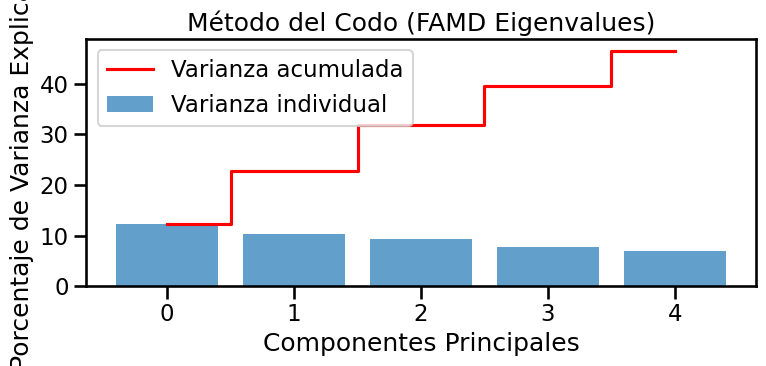

In [34]:
# 3. Previsualización de la Varianza (Elbow Method)
# En versiones recientes de prince, obtenemos los autovalores y la varianza explicada directamente
eigenvalues = famd.eigenvalues_
explained_inertia = famd.percentage_of_variance_

plt.figure(figsize=(8, 4))
plt.bar(range(len(explained_inertia)), explained_inertia, alpha=0.7, align='center', label='Varianza individual')
plt.step(range(len(explained_inertia)), np.cumsum(explained_inertia), where='mid', label='Varianza acumulada', color='red')
plt.ylabel('Porcentaje de Varianza Explicada')
plt.xlabel('Componentes Principales')
plt.title('Método del Codo (FAMD Eigenvalues)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

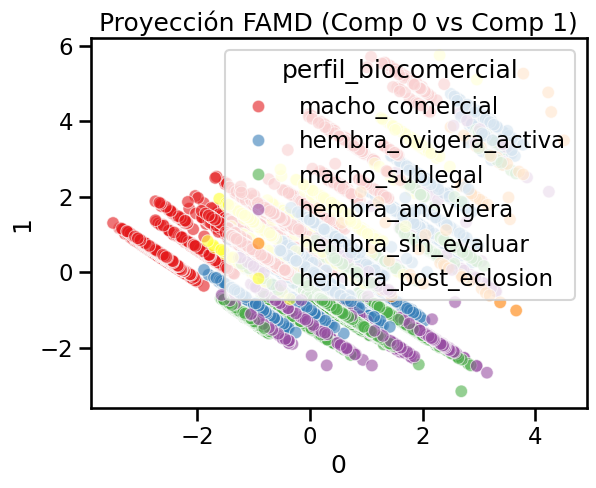

In [35]:
# 4. PREVISUALIZACIÓN CLAVE: Scatter de las Componentes 0 y 1
# Coloreamos por un feature clave para ver si hay separación natural
sns.scatterplot(
    x=coordenadas_famd[0],
    y=coordenadas_famd[1],
    hue=X_cluster['perfil_biocomercial'],
    alpha=0.6,
    palette='Set1'
)
plt.title("Proyección FAMD (Comp 0 vs Comp 1)")
plt.show()

## Etapa 2: Agrupamiento Espacial Basado en Densidad (HDBSCAN)

Las coordenadas extraídas del FAMD (coordenadas_famd) son exclusivamente numéricas y ortogonales, el alimento perfecto para distancias euclidianas en HDBSCAN.

In [36]:
import hdbscan

# 1. Instanciar HDBSCAN
# min_cluster_size: El tamaño mínimo para considerar un grupo como "clúster" válido.
# Para ~8800 registros, 50 a 150 es un buen rango inicial para evitar micro-clústeres.
# min_samples: Controla el conservadurismo de la agrupación (mayor valor = más ruido/outliers descartados).
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=100,
    min_samples=30,
    metric='euclidean',
    cluster_selection_method='eom' # Excess of Mass (busca clústeres más estables)
)

# 2. Ajustar el modelo usando las coordenadas extraídas de FAMD
# Nota: Convertimos a numpy array para optimizar rendimiento
cluster_labels = clusterer.fit_predict(coordenadas_famd.to_numpy())

# 3. Extraer resultados
X_cluster_resultados = X_cluster.copy()
X_cluster_resultados['Cluster_ID'] = cluster_labels
X_cluster_resultados['Probabilidad_Cluster'] = clusterer.probabilities_

# HDBSCAN etiqueta el ruido (outliers) con -1
print("Distribución de Clústeres:")
print(X_cluster_resultados['Cluster_ID'].value_counts())

Distribución de Clústeres:
Cluster_ID
-1     1898
 2      531
 18     485
 24     416
 25     408
 9      391
 6      349
 5      332
 4      314
 16     312
 20     266
 10     263
 27     263
 7      261
 21     258
 3      207
 0      201
 1      200
 15     187
 22     168
 23     158
 19     146
 13     138
 11     131
 26     129
 17     123
 14     112
 8      111
 12     102
Name: count, dtype: int64


In [37]:
# En prince 0.21.0+ se utiliza percentage_of_variance_ para conocer la inercia/varianza explicada
famd.percentage_of_variance_

array([12.33362386, 10.3471421 ,  9.23310814,  7.6780459 ,  6.96464237])

---
# Nueva estrategia de Clustering


In [38]:
# 1. Copia de seguridad del dataframe de entrenamiento
X_model = X_cluster.copy()

# 2. Transformación logarítmica de la asimetría (Skewness)
# Usamos log1p (log(x + 1)) por seguridad matemática ante posibles ceros en los datos crudos
X_model['profundidad_log'] = np.log1p(X_model['profundidad'])
X_model['num_trampas_log'] = np.log1p(X_model['num_trampas'])

# 3. Descartamos las variables originales para no tener multicolinealidad
X_model = X_model.drop(columns=['profundidad', 'num_trampas'])

print("Asimetría corregida. Columnas listas para modelar.")

Asimetría corregida. Columnas listas para modelar.


In [41]:
import prince
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# Asumimos que X_model_famd no incluye 'localizacion' si tiene cardinalidad extrema
# X_model_famd = X_model.drop(columns=['localizacion'])

print("--- Ejecutando FAMD + Ward ---")

# 1. Reducción de Dimensionalidad (FAMD)
# Buscamos capturar la varianza depurada de ruido
famd = prince.FAMD(
    n_components=5,
    n_iter=3,
    random_state=42,
    engine='sklearn'
)

# FAMD aplica su propio escalado internamente, le pasamos los datos crudos (con logaritmo)
coordenadas_famd = famd.fit_transform(X_model)

# En prince 0.21.0+, se utiliza percentage_of_variance_ en lugar de explained_inertia_
print(f"Varianza capturada por 5 componentes: {famd.percentage_of_variance_.sum()}%")

# 2. Clustering Aglomerativo (Ward)
# n_clusters=5 obliga al algoritmo a devolver 5 bloques compactos, sin "ruido" (-1)
ward = AgglomerativeClustering(
    n_clusters=5,
    metric='euclidean',
    linkage='ward'
)

# 3. Entrenamiento y asignación
etiquetas_ward = ward.fit_predict(coordenadas_famd)
X_cluster['Cluster_Ward'] = etiquetas_ward

# 4. Resultados
print("\nDistribución de Clústeres (Ward):")
print(X_cluster['Cluster_Ward'].value_counts().sort_index())

--- Ejecutando FAMD + Ward ---
Varianza capturada por 5 componentes: 46.77433528035812%

Distribución de Clústeres (Ward):
Cluster_Ward
0    1036
1    2574
2    2927
3     728
4    1595
Name: count, dtype: int64


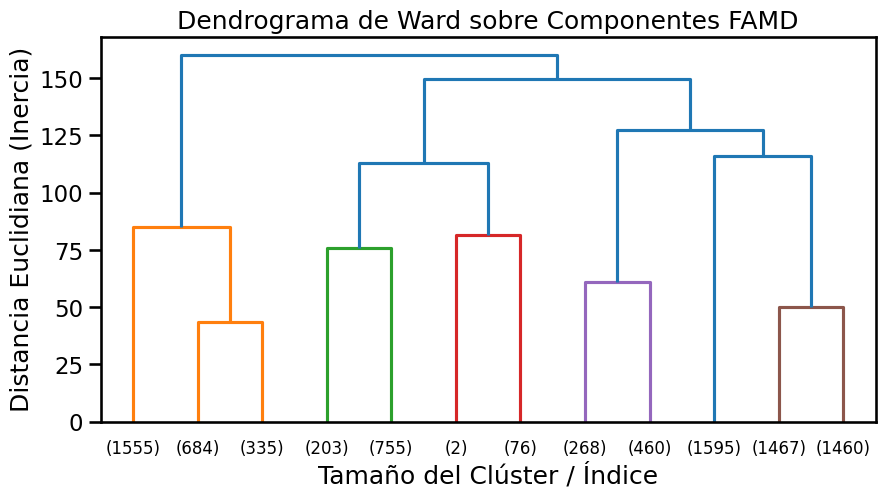

In [48]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Calcular la matriz de enlaces sobre los componentes de FAMD
matriz_enlace = linkage(coordenadas_famd, method='ward')

# Graficar Dendrograma
plt.figure(figsize=(10, 5))
dendrogram(matriz_enlace, truncate_mode='lastp', p=12)
plt.title('Dendrograma de Ward sobre Componentes FAMD')
plt.xlabel('Tamaño del Clúster / Índice')
plt.ylabel('Distancia Euclidiana (Inercia)')
plt.show()

# Implementación B: K-Prototypes Directo

Esta arquitectura es nativa para datos mixtos. Es la opción superior si decides reintegrar localizacion (incluso cruda), ya que K-Prototypes mide la distancia geográfica simplemente buscando si el nombre de la localización coincide o no (distancia de Hamming), sin multiplicar las dimensiones del dataset.

In [42]:
!pip install kmodes

In [45]:
newX_model = df_individuos.drop(columns=['fecha','tipo','especie','sexo',
                                        'madurez_sexual','latitud',
                                        'longitud']).copy()

# 2. Transformación logarítmica de la asimetría (Skewness)
# Usamos log1p (log(x + 1)) por seguridad matemática ante posibles ceros en los datos crudos
newX_model['profundidad_log'] = np.log1p(newX_model['profundidad'])
newX_model['num_trampas_log'] = np.log1p(newX_model['num_trampas'])

# 3. Descartamos las variables originales para no tener multicolinealidad
newX_model = newX_model.drop(columns=['profundidad', 'num_trampas'])

print("Asimetría corregida. Columnas listas para modelar.")


Asimetría corregida. Columnas listas para modelar.


In [46]:
# Requiere instalación previa: pip install kmodes
from kmodes.kprototypes import KPrototypes
from sklearn.preprocessing import StandardScaler

print("--- Ejecutando K-Prototypes ---")

# 1. Definición estricta de tipos de columnas
# Asegúrate de listar los nombres exactos de tu DataFrame
columnas_numericas = [
    'largo_caparazon', 'mes_sin', 'mes_cos',
    'ano_continuo', 'profundidad_log', 'num_trampas_log'
]
# Incluimos localización porque K-Prototypes lo maneja eficientemente
columnas_categoricas = ['perfil_biocomercial', 'estado_caparazon', 'localizacion']

X_kp = newX_model[columnas_numericas + columnas_categoricas].copy()

# 2. Estandarización obligatoria para numéricas (Z-score)
# Si no haces esto, 'ano_continuo' (ej. 1997.5) dominará sobre 'mes_sin' (ej. 0.8)
scaler = StandardScaler()
X_kp[columnas_numericas] = scaler.fit_transform(X_kp[columnas_numericas])

# 3. Identificación de índices categóricos (requerido por el algoritmo)
indices_categoricos = [X_kp.columns.get_loc(col) for col in columnas_categoricas]

# 4. Instanciar K-Prototypes
# init='Cao' es el método de inicialización más robusto para categorías
kp = KPrototypes(
    n_clusters=5,
    init='Cao',
    n_init=3, # Repite 3 veces y se queda con la mejor convergencia
    verbose=1,
    random_state=42,
    n_jobs=-1 # Usa todos los núcleos del procesador
)

# 5. Entrenamiento y asignación
# kp recibe un array de numpy, no un DataFrame directamente
etiquetas_kp = kp.fit_predict(X_kp.values, categorical=indices_categoricos)
X_cluster['Cluster_KP'] = etiquetas_kp

# 6. Resultados
print("\nDistribución de Clústeres (K-Prototypes):")
print(X_cluster['Cluster_KP'].value_counts().sort_index())

--- Ejecutando K-Prototypes ---
Initialization method and algorithm are deterministic. Setting n_init to 1.
Best run was number 2

Distribución de Clústeres (K-Prototypes):
Cluster_KP
0    2738
1    2002
2    1058
3    1070
4    1992
Name: count, dtype: int64


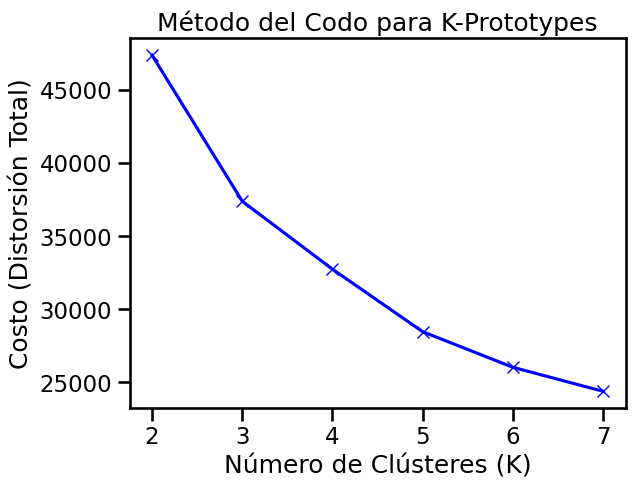

In [47]:
costos = []
K_rangos = range(2, 8)
for k in K_rangos:
  kp_test = KPrototypes(n_clusters=k, init='Cao', random_state=42, n_jobs=-1)
  kp_test.fit(X_kp.values, categorical=indices_categoricos)
  costos.append(kp_test.cost_)

plt.plot(K_rangos, costos, 'bx-')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Costo (Distorsión Total)')
plt.title('Método del Codo para K-Prototypes')
plt.show()

# Queda inspeccionar los 5 clusters obtenidos